In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Datasets/telecom_churn.csv")

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


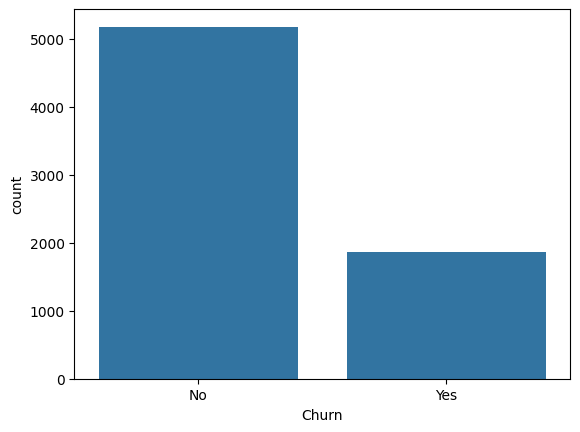

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=df)
plt.show()

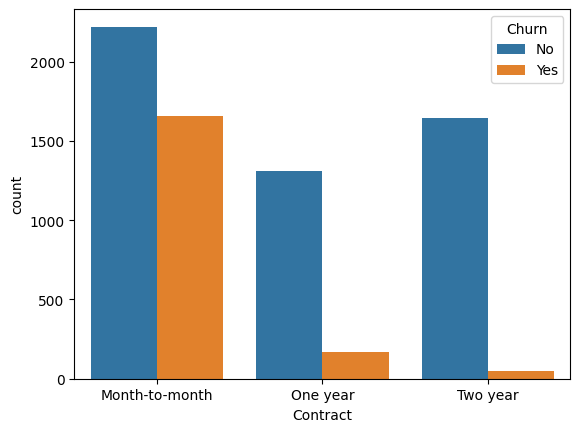

In [9]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.show()

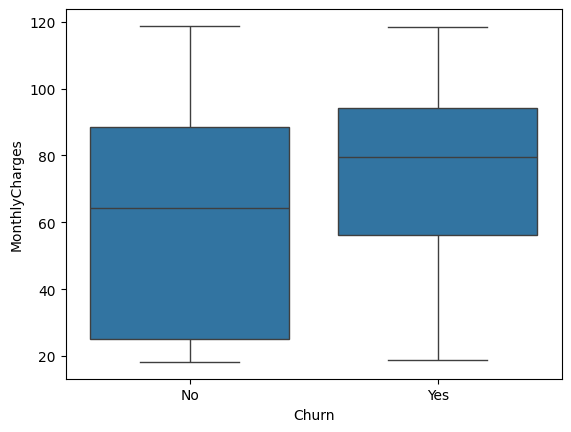

In [10]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()

In [11]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

In [13]:
df["charges_per_month"] = df["TotalCharges"] / (df["tenure"] + 1)

In [14]:
df["tenure_group"] = df["tenure"] // 12

In [15]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [17]:
y_pred = model.predict(X_test)

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.65      0.46      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.78      0.79      0.78      1407



In [19]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, model.predict_proba(X_test)[:,1])

np.float64(0.8180342805079437)

# Explainable AI (SHAP)

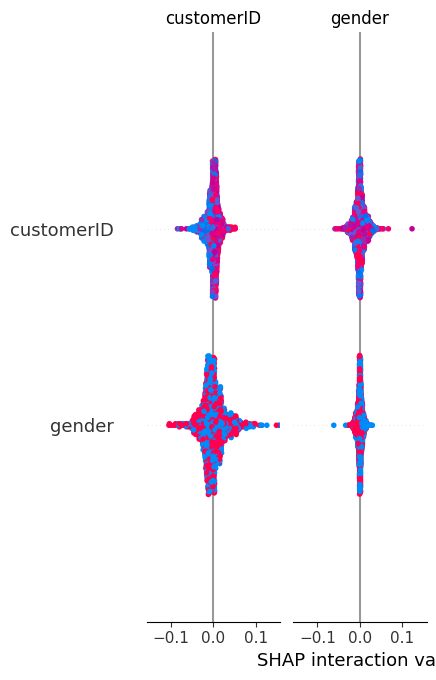

In [20]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [21]:
def retention_strategy(customer):

    if customer["MonthlyCharges"] > 80:
        return "Offer discount"

    elif customer["tenure"] < 6:
        return "Provide onboarding support"

    elif customer["Contract"] == 0:
        return "Promote yearly contract"

    else:
        return "Offer loyalty reward"

In [22]:
retention_strategy(X_test.iloc[0])

'Offer loyalty reward'

In [23]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)

df["segment"] = kmeans.fit_predict(X)

In [24]:
import pickle

pickle.dump(model, open("churn_model.pkl", "wb"))

In [25]:
from google.colab import files
files.download("churn_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
results = X_test.copy()
results["Actual_Churn"] = y_test
results["Predicted_Churn"] = y_pred
results["Churn_Probability"] = model.predict_proba(X_test)[:,1]

results.to_csv("churn_predictions.csv", index=False)

In [28]:
from google.colab import files
files.download("churn_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>